# Group No. 1 DDA IMage Feature Extraction Code
1. Samiksha Garibe A049
2. Lakshmi Prasanna V A004
3. Saity Pramanick A053
4. Poorvi Singh Samant A062
5. A038 Samiksha Tomar

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_hub as hub
from tensorflow.keras import layers

In [2]:
from google.colab import drive

# Mount to /content/drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Access your data through the mounted drive
data_path = '/content/drive/MyDrive/dda_3/acne_data' # Path to your data within the drive

In [4]:
!pip install split-folders
import splitfolders
splitfolders.ratio('/content/drive/MyDrive/dda_3/acne_data', output="output", seed=1337, ratio=(0.8, 0.2))

Copying files: 999 files [00:09, 102.00 files/s]


In [9]:

# Setup data inputs
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Preprocess data (get all of the pixel values between 0 & 1, also called scaling/normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup paths to our data directories
train_dir = "/content/output/train/"
test_dir = "/content/output/val/"

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               batch_size=16,
                                               target_size=(224, 224),
                                               class_mode="categorical",
                                               seed=42)
valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=16,
                                               target_size=(224, 224),
                                               class_mode="categorical",
                                               seed=42)

Found 798 images belonging to 3 classes.
Found 201 images belonging to 3 classes.


In [6]:
efficientnet_url = "https://tfhub.dev/tensorflow/efficientnet/b0/feature-vector/1"

IMAGE_SHAPE = (224, 224)
BATCH_SIZE = 32

def create_model(model_url, num_classes=3):
  """
  Takes a TensorFlow Hub URL and creates a Keras Sequential model with it.

  Args:
    model_url(str): A TensorFlow Hub feature extraction URL.
    num_classes(int): Number of output neurons in the output layer,
      should be equal to number of target classes, default = 10

  Returns:
    An uncompiled Keras Sequential model with model_url as feature extractor
    layer and Dense output layer with num_classes output neurons.
  """
  # Download the pretrained model and save it as a Keras layer
  feature_extractor_layer = hub.KerasLayer(model_url,
                                           trainable = False,   # freeze the already learned patterns
                                           name="feature_extraction_layer",
                                           input_shape=IMAGE_SHAPE+(3,))  # define the input image shape
  # Create our image model
  model = tf.keras.Sequential([
     feature_extractor_layer,    # use the feature extraction layer as the base
     layers.Dense(num_classes, activation="softmax", name="output_layer")   # create our own output layer
  ])
  return model

In [7]:
!pip install tensorflow==2.15.0 tensorflow-hub keras==2.15.0

import tensorflow_hub as hub
import tensorflow as tf
from tensorflow.keras import layers

# ... (rest of your code)

def create_model(model_url, num_classes=3):
  """
  Takes a TensorFlow Hub URL and creates a Keras Sequential model with it.
  """
  # Download the pretrained model and save it as a Keras layer
  # Moved feature_extractor_layer definition inside create_model function
  feature_extractor_layer = hub.KerasLayer(model_url,
                                           trainable = False,   # freeze the already learned patterns
                                           name="feature_extraction_layer",
                                           input_shape=IMAGE_SHAPE+(3,))  # define the input image shape
  # Create our image model
  model = tf.keras.Sequential([
     tf.keras.layers.InputLayer(input_shape=IMAGE_SHAPE + (3,)), # Add an InputLayer
     feature_extractor_layer,
     layers.Dense(num_classes, activation="softmax", name="output_layer")
  ])
  return model

In [ ]:
#!ls /content/output/train/
#!ls /content/output/val/

In [8]:
# Create EfficientNet model
efficientnet_model = create_model(efficientnet_url,
                            num_classes=3)
# Compile
efficientnet_model.compile(loss="categorical_crossentropy",
                     optimizer=tf.keras.optimizers.Adam(),
                     metrics=["accuracy"])
# Fit the model
efficientnet_history = efficientnet_model.fit(train_data,
                                  epochs=5,
                                  validation_data=valid_data)   # name of log files

Epoch 1/5
50/50 [==============================] - 77s 1s/step - loss: 0.9978 - accuracy: 0.4624 - val_loss: 0.9082 - val_accuracy: 0.5025
Epoch 2/5
50/50 [==============================] - 69s 1s/step - loss: 0.8878 - accuracy: 0.5301 - val_loss: 0.8285 - val_accuracy: 0.6020
Epoch 3/5
50/50 [==============================] - 65s 1s/step - loss: 0.8079 - accuracy: 0.6128 - val_loss: 0.7888 - val_accuracy: 0.6617
Epoch 4/5
50/50 [==============================] - 66s 1s/step - loss: 0.7702 - accuracy: 0.6554 - val_loss: 0.7701 - val_accuracy: 0.6567
Epoch 5/5
50/50 [==============================] - 63s 1s/step - loss: 0.7343 - accuracy: 0.6792 - val_loss: 0.7435 - val_accuracy: 0.6965


In [10]:
efficientnet_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 feature_extraction_layer (  (None, 1280)              4049564   
 KerasLayer)                                                     
                                                                 
 output_layer (Dense)        (None, 3)                 3843      
                                                                 
Total params: 4053407 (15.46 MB)
Trainable params: 3843 (15.01 KB)
Non-trainable params: 4049564 (15.45 MB)
_________________________________________________________________


In [11]:
efficientnet_model.save('saved_model/my_model')

In [12]:
acne_model = tf.keras.models.load_model('saved_model/my_model')

# Check its architecture
acne_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 feature_extraction_layer (  (None, 1280)              4049564   
 KerasLayer)                                                     
                                                                 
 output_layer (Dense)        (None, 3)                 3843      
                                                                 
Total params: 4053407 (15.46 MB)
Trainable params: 3843 (15.01 KB)
Non-trainable params: 4049564 (15.45 MB)
_________________________________________________________________


In [13]:
import pathlib
data_dir = pathlib.Path(train_dir)
acne_class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(acne_class_names)

['Level_0' 'Level_1' 'Level_2']


In [14]:
# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(filename, img_shape=224):
  """
  Reads in an image from filename, turns it into a tensor and reshapes into (224,224,3).
  """
  # Read in the image
  img = tf.io.read_file(filename)
  # Decode it into a tensor
  img = tf.image.decode_jpeg(img)
  # Resize the image
  img = tf.image.resize(img, [img_shape, img_shape])
  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

In [15]:
# Reconfig pred_and_plot function to work with multi-class images
def pred_and_plot(model, filename, class_names=acne_class_names):
  """
  Imports an image located at filename, makes a prediction with model
  and plots the image with the predicted class as the title.
  """
  # Import the target image and preprocess it
  img = load_and_prep_image(filename)

  # Make a prediction
  pred = model.predict(tf.expand_dims(img, axis=0))

  # Add in logic for multi-class & get pred_class name
  if len(pred[0]) > 1:
    pred_class = class_names[tf.argmax(pred[0])]
  else:
    pred_class = class_names[int(tf.round(pred[0]))]

  print('Prediction Probabilities : ', pred[0])

  # Plot the image and predicted class
  plt.imshow(img)
  plt.title(f"Prediction: {pred_class}")
  plt.axis(False);

1/1 [==============================] - 2s 2s/step
Prediction Probabilities :  [0.64848673 0.25841376 0.09309951]


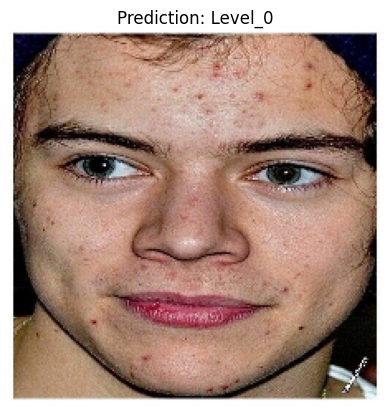

In [16]:
 pred_and_plot(model=acne_model,
              filename="/content/harry.jpg",
              class_names=acne_class_names)

#skin type model

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
!pip install split-folders
import splitfolders
splitfolders.ratio("/content/drive/MyDrive/skin_type ", output="output2", seed=1337, ratio=(0.8, 0.2))

Copying files: 1275 files [00:29, 43.31 files/s] 


In [22]:
# Setup data inputs
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Preprocess data (get all of the pixel values between 0 & 1, also called scaling/normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup paths to our data directories
train_dir = "/content/output2/train"
# Changed test_dir to val_dir to match the output of splitfolders.ratio()
val_dir = "/content/output2/val"


# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               target_size=(224, 224),
                                               class_mode="categorical",
                                               seed=42)
# Use val_dir instead of test_dir for valid_data
valid_data = valid_datagen.flow_from_directory(directory=val_dir,
                                               target_size=(224, 224),
                                               class_mode="categorical",
                                               seed=42)

Found 1016 images belonging to 3 classes.
Found 257 images belonging to 3 classes.


In [23]:
print(train_data.class_indices)
print(valid_data.class_indices)


{'dry': 0, 'normal': 1, 'oily': 2}
{'dry': 0, 'normal': 1, 'oily': 2}


In [24]:
efficientnet_url = "https://tfhub.dev/tensorflow/efficientnet/b0/feature-vector/1"

IMAGE_SHAPE = (224, 224)
BATCH_SIZE = 32

def create_model(model_url, num_classes=3):
  """
  Takes a TensorFlow Hub URL and creates a Keras Sequential model with it.

  Args:
    model_url(str): A TensorFlow Hub feature extraction URL.
    num_classes(int): Number of output neurons in the output layer,
      should be equal to number of target classes, default = 10

  Returns:
    An uncompiled Keras Sequential model with model_url as feature extractor
    layer and Dense output layer with num_classes output neurons.
  """
  # Download the pretrained model and save it as a Keras layer
  feature_extractor_layer = hub.KerasLayer(model_url,
                                           trainable = False,   # freeze the already learned patterns
                                           name="EfficientnetB0_model",
                                           input_shape=IMAGE_SHAPE+(3,))  # define the input image shape
  # Create our image model
  model = tf.keras.Sequential([
    feature_extractor_layer,    # use the feature extraction layer as the base
    layers.Dense(num_classes, activation="softmax", name="output_layer")   # create our own output layer
  ])
  return model

In [25]:
def create_model(model_url, num_classes=3):
    """
    Creates a Keras model using a TensorFlow Hub model as a feature extractor.
    Args:
      model_url (str): TensorFlow Hub URL for the model.
      num_classes (int): Number of output classes for classification.
    """
    # Input layer for 224x224 images with 3 channels (RGB)
    input_layer = tf.keras.layers.Input(shape=(224, 224, 3))
    print("Input layer defined")

    # Feature extractor from TensorFlow Hub (set trainable=False)
    feature_extractor_layer = hub.KerasLayer(model_url, trainable=False)
    print("Feature extractor layer created")

    # Wrap the feature extractor layer in a Lambda layer to handle the KerasTensor
    # This Lambda layer converts the KerasTensor to a regular TensorFlow tensor
    extracted_features = tf.keras.layers.Lambda(lambda x: feature_extractor_layer(x))(input_layer)
    print("Extracted features shape: ", extracted_features.shape)

    # Output layer with softmax activation for classification
    output_layer = tf.keras.layers.Dense(num_classes, activation="softmax")(extracted_features)
    print("Output layer created")

    # Create the model using Functional API
    model = tf.keras.Model(inputs=input_layer, outputs=output_layer)
    print("Model created")

    return model

In [26]:
# URL of EfficientNet B0 from TensorFlow Hub
efficientnet_url = "https://tfhub.dev/tensorflow/efficientnet/b0/feature-vector/1"

In [27]:
# Create the model
efficientnet_model = create_model(efficientnet_url, num_classes=3)

Input layer defined
Feature extractor layer created


The following Variables were used a Lambda layer's call (lambda), but
are not present in its tracked objects:
  <tf.Variable 'top_bn/beta:0' shape=(1280,) dtype=float32>
  <tf.Variable 'top_bn/gamma:0' shape=(1280,) dtype=float32>
  <tf.Variable 'top_conv2d/kernel:0' shape=(1, 1, 320, 1280) dtype=float32>
  <tf.Variable 'stack_6/block_0/project_bn/beta:0' shape=(320,) dtype=float32>
  <tf.Variable 'stack_6/block_0/project_bn/gamma:0' shape=(320,) dtype=float32>
  <tf.Variable 'stack_6/block_0/project_conv2d/kernel:0' shape=(1, 1, 1152, 320) dtype=float32>
  <tf.Variable 'stack_6/block_0/se_expand_conv2d/bias:0' shape=(1152,) dtype=float32>
  <tf.Variable 'stack_6/block_0/se_expand_conv2d/kernel:0' shape=(1, 1, 48, 1152) dtype=float32>
  <tf.Variable 'stack_6/block_0/se_reduce_conv2d/bias:0' shape=(48,) dtype=float32>
  <tf.Variable 'stack_6/block_0/se_reduce_conv2d/kernel:0' shape=(1, 1, 1152, 48) dtype=float32>
  <tf.Variable 'stack_6/block_0/depthwise_bn/beta:0' shape=(1152,) dtype=f

Extracted features shape:  (None, 1280)
Output layer created
Model created


In [28]:
# Compile
efficientnet_model.compile(loss="categorical_crossentropy",
                     optimizer=tf.keras.optimizers.Adam(),
                     metrics=["accuracy"])

In [29]:
efficientnet_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 lambda (Lambda)             (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 3)                 3843      
                                                                 
Total params: 3843 (15.01 KB)
Trainable params: 3843 (15.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [30]:
# Fit the model
efficientnet_history = efficientnet_model.fit(train_data,
                                  epochs=5,
                                  validation_data=valid_data)   # name of log files

Epoch 1/5
32/32 [==============================] - 177s 3s/step - loss: 0.9378 - accuracy: 0.5778 - val_loss: 0.8171 - val_accuracy: 0.6537
Epoch 2/5
32/32 [==============================] - 89s 3s/step - loss: 0.7061 - accuracy: 0.7205 - val_loss: 0.7158 - val_accuracy: 0.7237
Epoch 3/5
32/32 [==============================] - 94s 3s/step - loss: 0.6083 - accuracy: 0.7766 - val_loss: 0.6621 - val_accuracy: 0.7393
Epoch 4/5
32/32 [==============================] - 94s 3s/step - loss: 0.5509 - accuracy: 0.8041 - val_loss: 0.6284 - val_accuracy: 0.7393
Epoch 5/5
32/32 [==============================] - 91s 3s/step - loss: 0.5053 - accuracy: 0.8238 - val_loss: 0.6003 - val_accuracy: 0.7626


In [31]:
import pathlib
data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['dry' 'normal' 'oily']


In [32]:
# Reconfig pred_and_plot function to work with multi-class images
def pred_and_plot(model, filename, class_names=class_names):
  """
  Imports an image located at filename, makes a prediction with model
  and plots the image with the predicted class as the title.
  """
  # Import the target image and preprocess it
  img = load_and_prep_image(filename)

  # Make a prediction
  pred = model.predict(tf.expand_dims(img, axis=0))

  # Add in logic for multi-class & get pred_class name
  if len(pred[0]) > 1:
    pred_class = class_names[tf.argmax(pred[0])]
  else:
    pred_class = class_names[int(tf.round(pred[0]))]

  print('Prediction Probabilities : ', pred[0])

  # Plot the image and predicted class
  plt.imshow(img)
  plt.title(f"Prediction: {pred_class}")
  plt.axis(False);

1/1 [==============================] - 1s 1s/step
Prediction Probabilities :  [0.79390305 0.1027635  0.10333344]


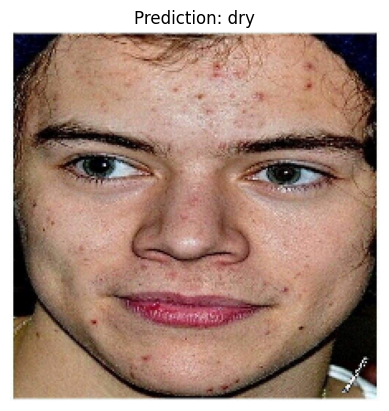

In [33]:
# Make a prediction using model_1
pred_and_plot(model=efficientnet_model,
              filename="/content/harry.jpg",
              class_names=class_names)

In [34]:
# Assuming `efficientnet_model` is your skin type model
# Assuming `acne_model` is your acne level model
# Assuming `class_names` is the list of class names for skin type model
# Assuming `class_names_acne` is the list of class names for acne model

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Define a function that takes an image path and predicts skin type and acne level
def predict_skin_attributes(image_path, acne_model, efficientnet_model, class_names, class_names_acne):
    # Load and preprocess the image
    img = load_and_prep_image(image_path)

    # Make predictions with both models
    acne_pred = acne_model.predict(tf.expand_dims(img, axis=0))
    skin_type_pred = efficientnet_model.predict(tf.expand_dims(img, axis=0))

    # Get predicted class names for both models
    acne_class = acne_class_names[tf.argmax(acne_pred[0])]
    skin_type_class = class_names[tf.argmax(skin_type_pred[0])]

    # Print predictions and their probabilities
    print(f"Acne Level: {acne_class}, Prediction Probabilities: {acne_pred[0]}")
    print(f"Skin Type: {skin_type_class}, Prediction Probabilities: {skin_type_pred[0]}")

    # Combine predictions into a single user vector
    user_vector = np.concatenate((acne_pred[0], skin_type_pred[0]))
    return user_vector

# Path to the input image
image_path = '/content/harry.jpg'  # Replace with the path to your test image

# Get the user vector for recommendation
user_vector = predict_skin_attributes(image_path, acne_model, efficientnet_model, class_names, acne_class_names)



1/1 [==============================] - 0s 73ms/step
Acne Level: Level_0, Prediction Probabilities: [0.64848673 0.25841376 0.09309951]
Skin Type: dry, Prediction Probabilities: [0.79390305 0.1027635  0.10333344]


In [35]:
import matplotlib.pyplot as plt
import tensorflow as tf

def pred_and_plot_both_models(image_path, acne_model, efficientnet_model, class_names_acne, class_names_skin):
    """
    Loads an image, predicts acne level and skin type, and displays the image with predictions.
    Args:
        image_path (str): Path to the input image.
        acne_model: Trained model for acne level detection.
        efficientnet_model: Trained model for skin type detection.
        class_names_acne (list): Class names for acne model (e.g., ["level0", "level1", "level2"]).
        class_names_skin (list): Class names for skin type model (e.g., ["oily", "dry", "normal"]).
    """
    # Load and preprocess the image
    img = load_and_prep_image(image_path)

    # Make predictions using both models
    acne_pred = acne_model.predict(tf.expand_dims(img, axis=0))
    skin_type_pred = efficientnet_model.predict(tf.expand_dims(img, axis=0))

    # Get predicted classes
    acne_class = acne_class_names[tf.argmax(acne_pred[0])]
    skin_type_class = class_names_skin[tf.argmax(skin_type_pred[0])]

    # Display the predictions
    print(f"Acne Level: {acne_class}, Prediction Probabilities: {acne_pred[0]}")
    print(f"Skin Type: {skin_type_class}, Prediction Probabilities: {skin_type_pred[0]}")

    # Plot the image with predictions as overlay text
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Skin Type: {skin_type_class} ({max(skin_type_pred[0]):.2f}) | Acne Level: {acne_class} ({max(acne_pred[0]):.2f})", fontsize=12)
    plt.show()




1/1 [==============================] - 0s 76ms/step
Acne Level: Level_0, Prediction Probabilities: [0.64848673 0.25841376 0.09309951]
Skin Type: dry, Prediction Probabilities: [0.79390305 0.1027635  0.10333344]


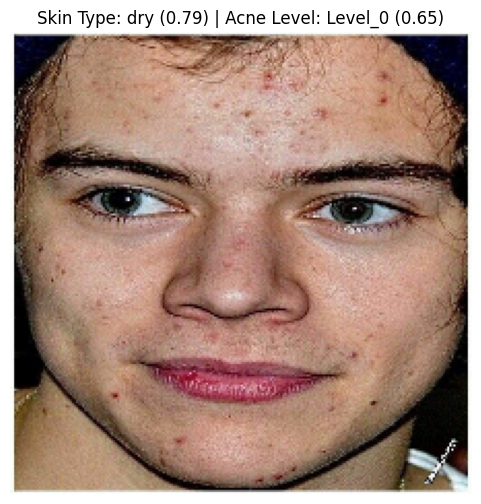

In [36]:
image_path = "/content/harry.jpg"
pred_and_plot_both_models(image_path, acne_model, efficientnet_model, acne_class_names, class_names)

1/1 [==============================] - 0s 105ms/step
Acne Level: Level_0, Prediction Probabilities: [0.48435292 0.20021443 0.31543264]
Skin Type: normal, Prediction Probabilities: [0.3968616  0.4644441  0.13869426]


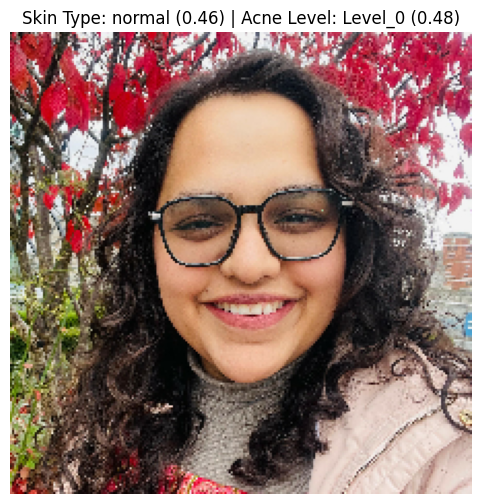

In [ ]:
image_path = "/content/ishi.jpg"
pred_and_plot_both_models(image_path, acne_model, efficientnet_model, acne_class_names, class_names)